In [7]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm

### purpose is to explore what humidity, and wind profiles look like across the day for wet and dry apes, discern differences

In [8]:
# removes underground values, contains advections and mean wind profiles

with open('/home/annierosen16/master_clean.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [9]:
mean_surface_pressure = np.nanmean(master['average_sp']) / 100
 
mean_surface_pressure

931.9282427656697

In [2]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

q_files = get_files('specific_humidity', 'specific_humidity')

all_files = u_files + v_files + q_files + w_files

# open all datasets at once

uvwq = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

In [10]:
uvwq_sgp = uvwq.sel(
    
    latitude=slice(39, 30),
    
    longitude=slice(-105, -95)
)

uvwq_sgp['time'] = uvwq_sgp['time'] - pd.Timedelta(hours=6)

uvwq_sgp = uvwq_sgp.where(
    
    (uvwq_sgp.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (uvwq_sgp.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

uvwq_sgp["w"] = uvwq_sgp["w"] * -1

#### separating by hour of the day

In [11]:
_0lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 0)

_3lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 3)

_6lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 6)

_9lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 9)

_12lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 12)

_15lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 15)

_18lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 18)

_21lst = uvwq_sgp.sel(time=uvwq_sgp.time.dt.hour == 21)

#### defining dry apes (or coupling) and wet apes (or coupling) with surface pressure in order to account for topography in composites

In [13]:
dryapes = master[master['dryape']==True][['date','latitude','longitude', 'average_sp']]

wetapes = master[master['wetape']==True][['date','latitude','longitude','average_sp']]

drycoup = master[(master['dryape']==False) & (master['drycoupling']==True)][['date','latitude','longitude', 'average_sp']]

wetcoup = master[(master['wetape']==False) & (master['wetcoupling']==True)][['date','latitude','longitude','average_sp']]

#### dryapes vertical velocity composites for all times of day

In [ ]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

dryapes['date'] = pd.to_datetime(dryapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    w_profiles = ds.sel(
        
        time=xr.DataArray(dryapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(dryapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(dryapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['w']
    
    sp_expanded = np.expand_dims(dryapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    w_profiles_masked = w_profiles.where(pressure_levels < sp_expanded)

    w_profiles_np = w_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(w_profiles_np, axis=0)
    
    print(time_label, "complete")

w_dryapes_all_times = pd.DataFrame(composite_profiles)

0 LST complete
3 LST complete
6 LST complete
9 LST complete
12 LST complete
15 LST complete
18 LST complete


#### wetapes vertical velocity composites for all times of day

In [9]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

wetapes['date'] = pd.to_datetime(wetapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    w_profiles = ds.sel(
        
        time=xr.DataArray(wetapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(wetapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(wetapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['w']
    
    sp_expanded = np.expand_dims(wetapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    w_profiles_masked = w_profiles.where(pressure_levels < sp_expanded)

    w_profiles_np = w_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(w_profiles_np, axis=0)
    
    print(time_label, "complete")

w_wetapes_all_times = pd.DataFrame(composite_profiles)

0 LST complete
3 LST complete
6 LST complete
9 LST complete
12 LST complete
15 LST complete
18 LST complete
21 LST complete


#### plots of vertical velocity for dry and wet apes

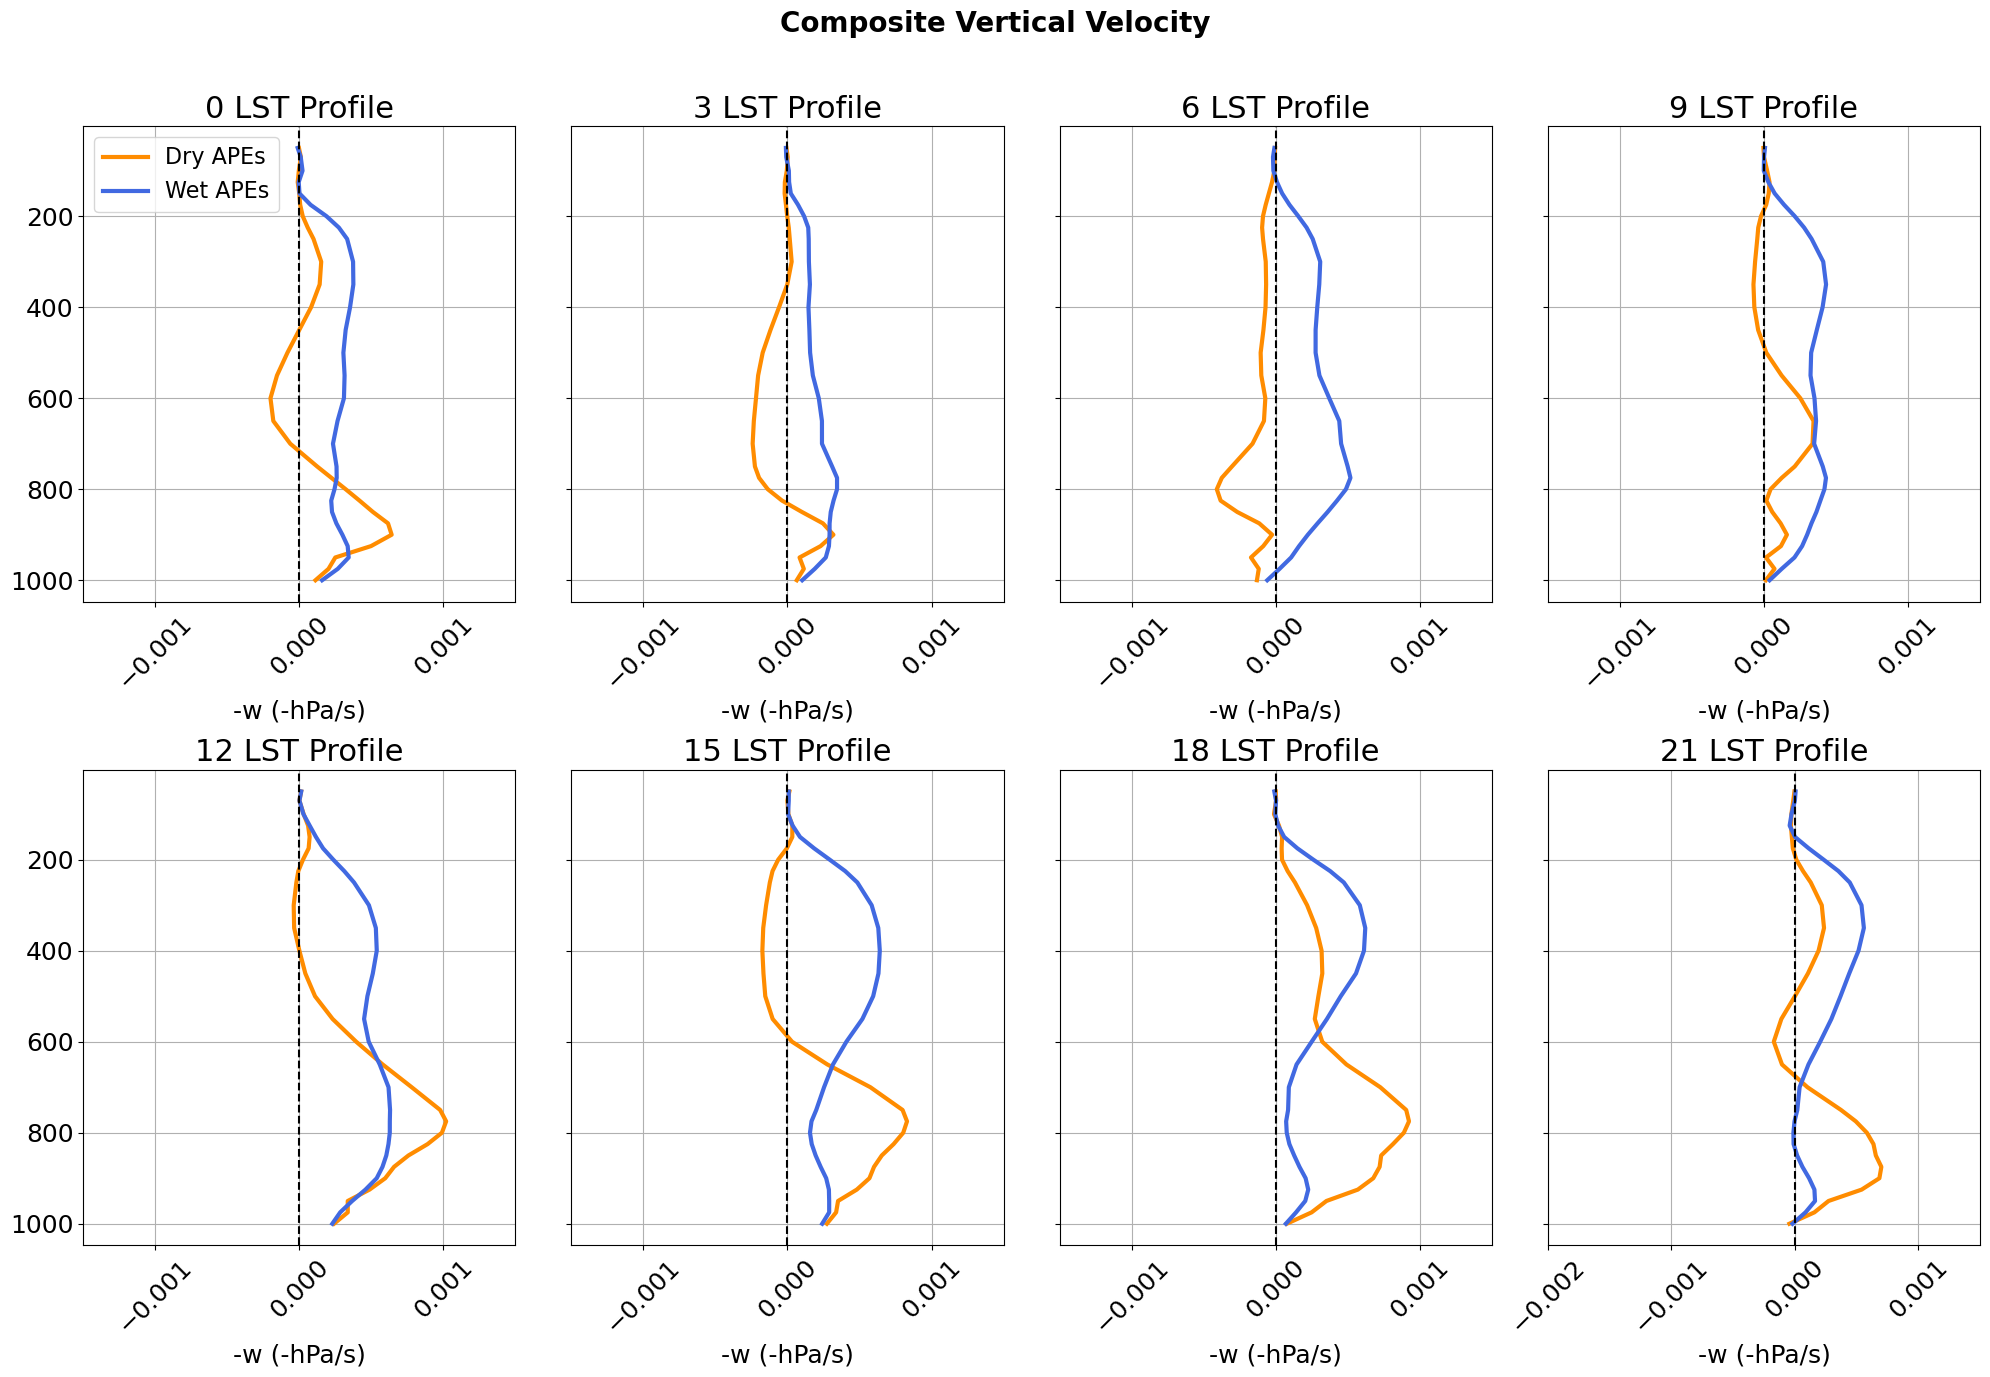

In [10]:
pressure = _0lst['level'].data  # Assuming this is consistent for both dry and wet cases

profile_columns = [col for col in w_dryapes_all_times.columns]

wet_color = "#4169E1"  # Royal Blue

dry_color = "#FF8C00"  # Dark Orange

num_profiles = len(profile_columns)

rows = 2
cols = min(4, num_profiles)  # Ensures no extra empty columns

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), sharey=True)
axes = np.ravel(axes)  # Flatten in case of 2D array


# Loop through each column (each time of day) and plot dry and wet profiles
for i, (ax, col) in enumerate(zip(axes, profile_columns)):
    
    # Plot the dry and wet profiles
    ax.plot(w_dryapes_all_times[col] / 100, pressure, label=f'Dry APEs', color=dry_color, linewidth=3)
    
    ax.plot(w_wetapes_all_times[col] / 100, pressure, label=f'Wet APEs', color=wet_color, linewidth=3)
    
    ax.invert_yaxis()  # Invert for atmospheric convention
    
    ax.set_xlim(-0.0015, 0.0015)  # Set x-axis limits
    
    ax.set_title(f'{col} Profile', fontsize=22)  # Title with hour label
    
    ax.set_xlabel('-w (-hPa/s)', fontsize=18)  # x-label
    
    ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size
    
    ax.tick_params(axis='x', rotation=45)  # Rotates x-tick labels by 45 degrees
    
    # Remove the last x-tick from the rightmost subplot
    if i == (len(profile_columns) - 1):  # If it's the rightmost subplot
        ticks = ax.get_xticks()  # Get current ticks
        ticks = ticks[:-1]  # Remove the last tick
        ax.set_xticks(ticks)  # Set the modified ticks
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)  # Zero reference line
    
    ax.grid(True)
    
    # Add legend only to the first subplot
    if i == 0:
        ax.legend(fontsize=16, loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Leaves space at the top for the suptitle

plt.suptitle("Composite Vertical Velocity", fontsize=20, fontweight='bold', y=0.98)

plt.gca().invert_yaxis()

plt.show()

#### dryapes specific humidity composites for all times of day

In [ ]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

dryapes['date'] = pd.to_datetime(dryapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    q_profiles = ds.sel(
        
        time=xr.DataArray(dryapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(dryapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(dryapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['q']
    
    sp_expanded = np.expand_dims(dryapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    q_profiles_masked = q_profiles.where(pressure_levels < sp_expanded)

    q_profiles_np = q_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(q_profiles_np, axis=0)
    
    print(time_label, "complete")

q_dryapes_all_times = pd.DataFrame(composite_profiles)

0 LST complete
3 LST complete
6 LST complete
9 LST complete
12 LST complete
15 LST complete
18 LST complete


#### wetapes specific humidity composites for all times of day

In [12]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

wetapes['date'] = pd.to_datetime(wetapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    q_profiles = ds.sel(
        
        time=xr.DataArray(wetapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(wetapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(wetapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['q']
    
    sp_expanded = np.expand_dims(wetapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    q_profiles_masked = q_profiles.where(pressure_levels < sp_expanded)

    q_profiles_np = q_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(q_profiles_np, axis=0)
    
    print(time_label, "complete")

q_wetapes_all_times = pd.DataFrame(composite_profiles)

0 LST complete
3 LST complete
6 LST complete
9 LST complete
12 LST complete
15 LST complete
18 LST complete
21 LST complete


#### composite q profiles plotted

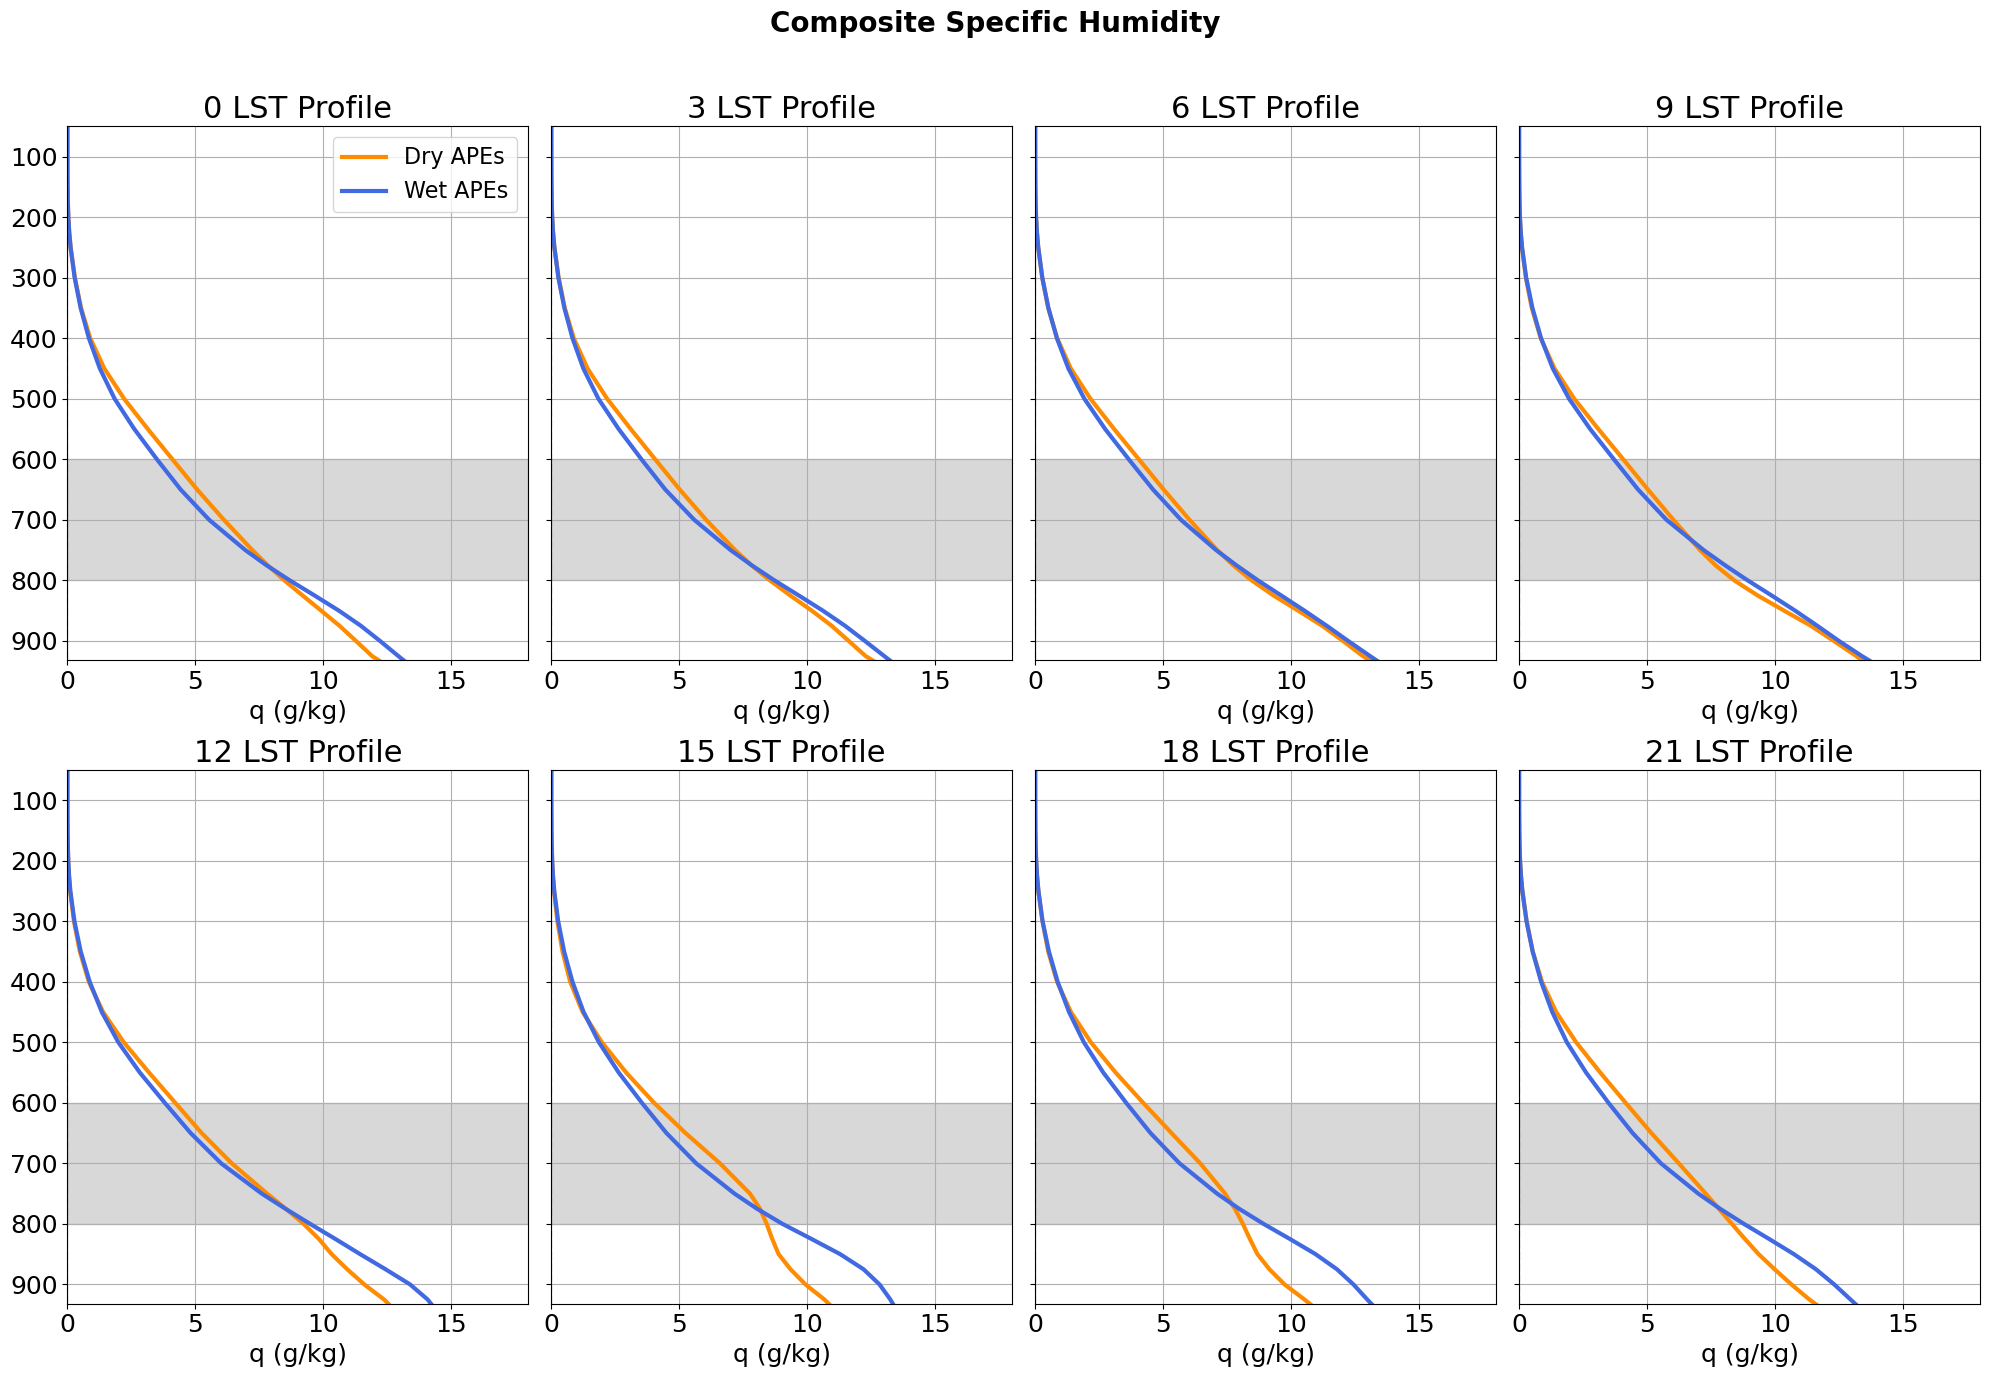

In [13]:
q_wetapes_all_times_gkg = q_wetapes_all_times * 1000

q_dryapes_all_times_gkg = q_dryapes_all_times * 1000

pressure = _0lst['level'].data  # Assuming this is consistent for both dry and wet cases

profile_columns = [col for col in q_dryapes_all_times.columns]

wet_color = "#4169E1"  # Royal Blue

dry_color = "#FF8C00"  # Dark Orange

num_profiles = len(profile_columns)

rows = 2

cols = min(4, num_profiles)  # Ensures no extra empty columns

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), sharey=True)

axes = np.ravel(axes)  # Flatten in case of 2D array

# Define pressure levels to shade
shade_min = 800  # hPa

shade_max = 600  # hPa

# Loop through each column (each time of day) and plot dry and wet profiles
for i, (ax, col) in enumerate(zip(axes, profile_columns)):
    
    # Plot the dry and wet profiles
    ax.plot(q_dryapes_all_times_gkg[col] , pressure, label=f'Dry APEs', color=dry_color, linewidth=3)
    
    ax.plot(q_wetapes_all_times_gkg[col] , pressure, label=f'Wet APEs', color=wet_color, linewidth=3)
    
    # Shade the 800-600 hPa region
    ax.fill_betweenx(pressure, 0, 18, 
                     where=(pressure <= shade_min) & (pressure >= shade_max), 
                     color='gray', alpha=0.3)
    
    ax.invert_yaxis()  # Invert for atmospheric convention
    
    ax.set_xlim(0, 18)  # Set x-axis limits
    
    ax.set_title(f'{col} Profile', fontsize=22)  # Title with hour label
    
    ax.set_xlabel('q (g/kg)', fontsize=18)  # x-label
    
    ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)  # Zero reference line
    
    ax.grid(True)
    
    ax.set_ylim(mean_surface_pressure, np.min(pressure))
    
    # Add legend only to the first subplot
    if i == 0:
        ax.legend(fontsize=16, loc='best')

plt.tight_layout()

# plt.gca().invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Leaves space at the top for the suptitle

plt.suptitle("Composite Specific Humidity", fontsize=20, fontweight='bold', y=0.98)

plt.show()

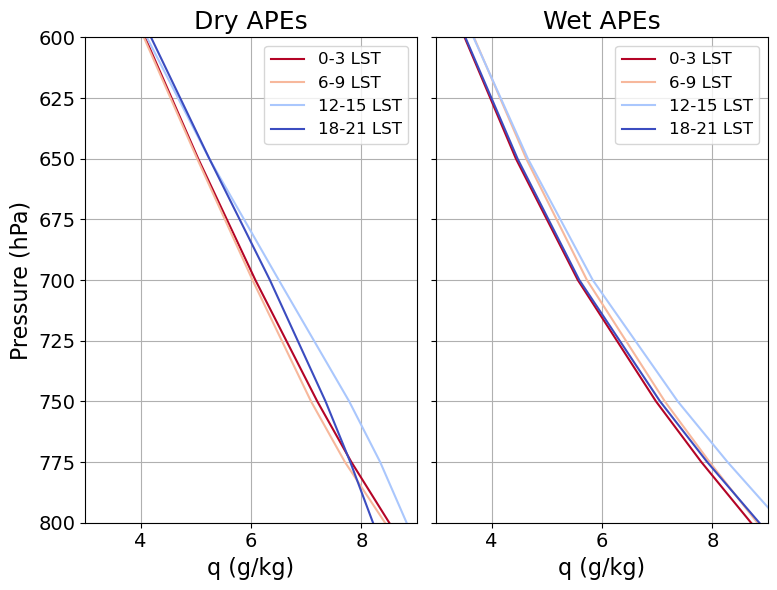

In [14]:
# Convert specific humidity to g/kg

q_wetapes_all_times_gkg = q_wetapes_all_times * 1000

q_dryapes_all_times_gkg = q_dryapes_all_times * 1000

pressure = _0lst['level'].data  # Assuming this is consistent for both dry and wet cases

# Define new time groups

time_groups = {
    "0-3 LST": ["0 LST", "3 LST"],
    "6-9 LST": ["6 LST", "9 LST"],
    "12-15 LST": ["12 LST", "15 LST"],
    "18-21 LST": ["18 LST", "21 LST"]
}

# Compute mean specific humidity for each group
q_dry_grouped = {label: q_dryapes_all_times_gkg[cols].mean(axis=1) for label, cols in time_groups.items()}

q_wet_grouped = {label: q_wetapes_all_times_gkg[cols].mean(axis=1) for label, cols in time_groups.items()}

# Generate distinct colors for different groups
colors = cm.coolwarm_r(np.linspace(0, 1, len(time_groups)))

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# --- Dry APEs Figure ---
ax_dry = axes[0]

for (label, q_profile), color in zip(q_dry_grouped.items(), colors):
    ax_dry.plot(q_profile, pressure, label=label, color=color, linewidth=1.5)

# Shade the 800-600 hPa region
shade_min, shade_max = 800, 600

# ax_dry.fill_betweenx(pressure, 0, 18, where=(pressure <= shade_min) & (pressure >= shade_max), 
#                       color='gray', alpha=0.3)

ax_dry.invert_yaxis()  # Invert for atmospheric convention

ax_dry.set_xlim(3, 9)  # Set x-axis limits

ax_dry.set_title('Dry APEs', fontsize=18)

ax_dry.set_xlabel('q (g/kg)', fontsize=16)

ax_dry.set_ylabel('Pressure (hPa)', fontsize=16)

ax_dry.tick_params(axis='both', which='major', labelsize=14)

ax_dry.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Zero reference line

ax_dry.grid(True)

# Add legend
ax_dry.legend(fontsize=12, loc='best')

# --- Wet APEs Figure ---
ax_wet = axes[1]
for (label, q_profile), color in zip(q_wet_grouped.items(), colors):
    
    ax_wet.plot(q_profile, pressure, label=label, color=color, linewidth=1.5)

ax_wet.invert_yaxis()  # Invert for atmospheric convention

ax_wet.set_xlim(3, 9)  # Set x-axis limits

ax_wet.set_title('Wet APEs', fontsize=18)

ax_wet.set_xlabel('q (g/kg)', fontsize=16)

ax_wet.tick_params(axis='both', which='major', labelsize=14)

ax_wet.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Zero reference line

ax_wet.grid(True)

# Add legend

ax_wet.legend(fontsize=12, loc='best')

plt.tight_layout()

plt.gca().invert_yaxis()

plt.ylim(800, 600)

plt.xlim(3, 9)

plt.show()


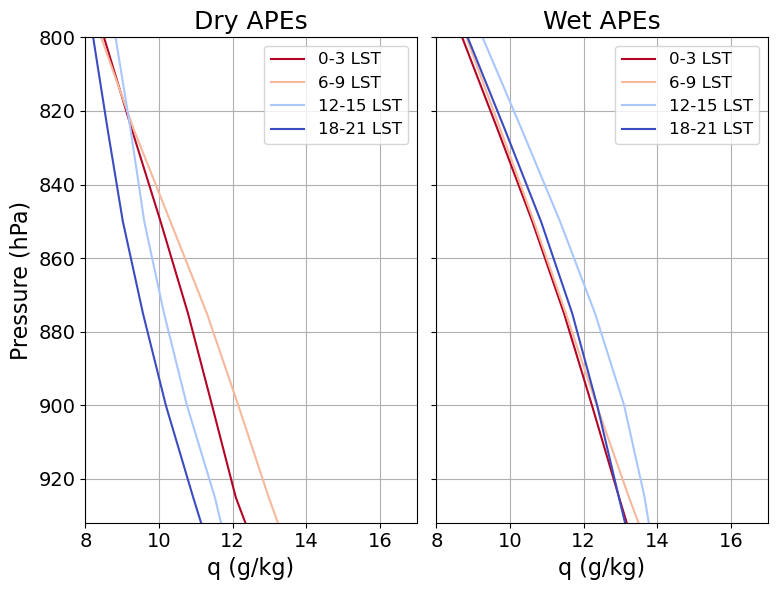

In [15]:
q_wetapes_all_times_gkg = q_wetapes_all_times * 1000

q_dryapes_all_times_gkg = q_dryapes_all_times * 1000

pressure = _0lst['level'].data  # Assuming this is consistent for both dry and wet cases

# Define new time groups

time_groups = {
    "0-3 LST": ["0 LST", "3 LST"],
    "6-9 LST": ["6 LST", "9 LST"],
    "12-15 LST": ["12 LST", "15 LST"],
    "18-21 LST": ["18 LST", "21 LST"]
}

# Compute mean specific humidity for each group
q_dry_grouped = {label: q_dryapes_all_times_gkg[cols].mean(axis=1) for label, cols in time_groups.items()}

q_wet_grouped = {label: q_wetapes_all_times_gkg[cols].mean(axis=1) for label, cols in time_groups.items()}

# Generate distinct colors for different groups
colors = cm.coolwarm_r(np.linspace(0, 1, len(time_groups)))

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# --- Dry APEs Figure ---
ax_dry = axes[0]

for (label, q_profile), color in zip(q_dry_grouped.items(), colors):
    ax_dry.plot(q_profile, pressure, label=label, color=color, linewidth=1.5)

# Shade the 800-600 hPa region
shade_min, shade_max = 800, 600

# ax_dry.fill_betweenx(pressure, 0, 18, where=(pressure <= shade_min) & (pressure >= shade_max), 
#                       color='gray', alpha=0.3)

ax_dry.invert_yaxis()  # Invert for atmospheric convention

ax_dry.set_xlim(8, 17)  # Set x-axis limits

ax_dry.set_title('Dry APEs', fontsize=18)

ax_dry.set_xlabel('q (g/kg)', fontsize=16)

ax_dry.set_ylabel('Pressure (hPa)', fontsize=16)

ax_dry.tick_params(axis='both', which='major', labelsize=14)

ax_dry.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Zero reference line

ax_dry.grid(True)

# Add legend
ax_dry.legend(fontsize=12, loc='best')

# --- Wet APEs Figure ---
ax_wet = axes[1]
for (label, q_profile), color in zip(q_wet_grouped.items(), colors):
    ax_wet.plot(q_profile, pressure, label=label, color=color, linewidth=1.5)

# Shade the 800-600 hPa region
# ax_wet.fill_betweenx(pressure, 0, 18, where=(pressure <= shade_min) & (pressure >= shade_max), 
#                       color='gray', alpha=0.3)

ax_wet.invert_yaxis()  # Invert for atmospheric convention

ax_wet.set_xlim(8, 17)  # Set x-axis limits

ax_wet.set_title('Wet APEs', fontsize=18)

ax_wet.set_xlabel('q (g/kg)', fontsize=16)

ax_wet.tick_params(axis='both', which='major', labelsize=14)

ax_wet.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Zero reference line

ax_wet.grid(True)

# Add legend

ax_wet.legend(fontsize=12, loc='best')

plt.tight_layout()

plt.gca().invert_yaxis()

plt.ylim(mean_surface_pressure, 800)

# plt.xlim(2, 10)

plt.show()

#### dry apes (or coupling) meridional wind speed

In [14]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

drycoup['date'] = pd.to_datetime(drycoup['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    v_profiles = ds.sel(
        
        time=xr.DataArray(drycoup['date'].values, dims="points"),
        
        latitude=xr.DataArray(drycoup['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(drycoup['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['v']
    
    print()
    
    sp_expanded = np.expand_dims(drycoup['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    v_profiles_masked = v_profiles.where(pressure_levels < sp_expanded)

    v_profiles_np = v_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(v_profiles_np, axis=0)
    
    print(time_label, "complete")

v_drycoup_all_times = pd.DataFrame(composite_profiles)


0 LST complete

3 LST complete

6 LST complete

9 LST complete

12 LST complete

15 LST complete

18 LST complete

21 LST complete


In [17]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

dryapes['date'] = pd.to_datetime(dryapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    v_profiles = ds.sel(
        
        time=xr.DataArray(dryapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(dryapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(dryapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['v']
    
    print()
    
    sp_expanded = np.expand_dims(dryapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    v_profiles_masked = v_profiles.where(pressure_levels < sp_expanded)

    v_profiles_np = v_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(v_profiles_np, axis=0)
    
    print(time_label, "complete")

v_dryapes_all_times = pd.DataFrame(composite_profiles)


0 LST complete

3 LST complete

6 LST complete

9 LST complete

12 LST complete

15 LST complete

18 LST complete

21 LST complete


#### wet apes (or coupling) meridional wind speed

In [15]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

wetcoup['date'] = pd.to_datetime(wetcoup['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    v_profiles = ds.sel(
        
        time=xr.DataArray(wetcoup['date'].values, dims="points"),
        
        latitude=xr.DataArray(wetcoup['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(wetcoup['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['v']
    
    sp_expanded = np.expand_dims(wetcoup['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    v_profiles_masked = v_profiles.where(pressure_levels < sp_expanded)

    v_profiles_np = v_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(v_profiles_np, axis=0)
    
    print(time_label, "complete")

v_wetcoup_all_times = pd.DataFrame(composite_profiles)

0 LST complete
3 LST complete
6 LST complete
9 LST complete
12 LST complete
15 LST complete
18 LST complete
21 LST complete


In [18]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

wetapes['date'] = pd.to_datetime(wetapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    v_profiles = ds.sel(
        
        time=xr.DataArray(wetapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(wetapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(wetapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['v']
    
    sp_expanded = np.expand_dims(wetapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    v_profiles_masked = v_profiles.where(pressure_levels < sp_expanded)

    v_profiles_np = v_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(v_profiles_np, axis=0)
    
    print(time_label, "complete")

v_wetapes_all_times = pd.DataFrame(composite_profiles)

0 LST complete
3 LST complete
6 LST complete
9 LST complete
12 LST complete
15 LST complete
18 LST complete
21 LST complete


#### plot meridional wind speed

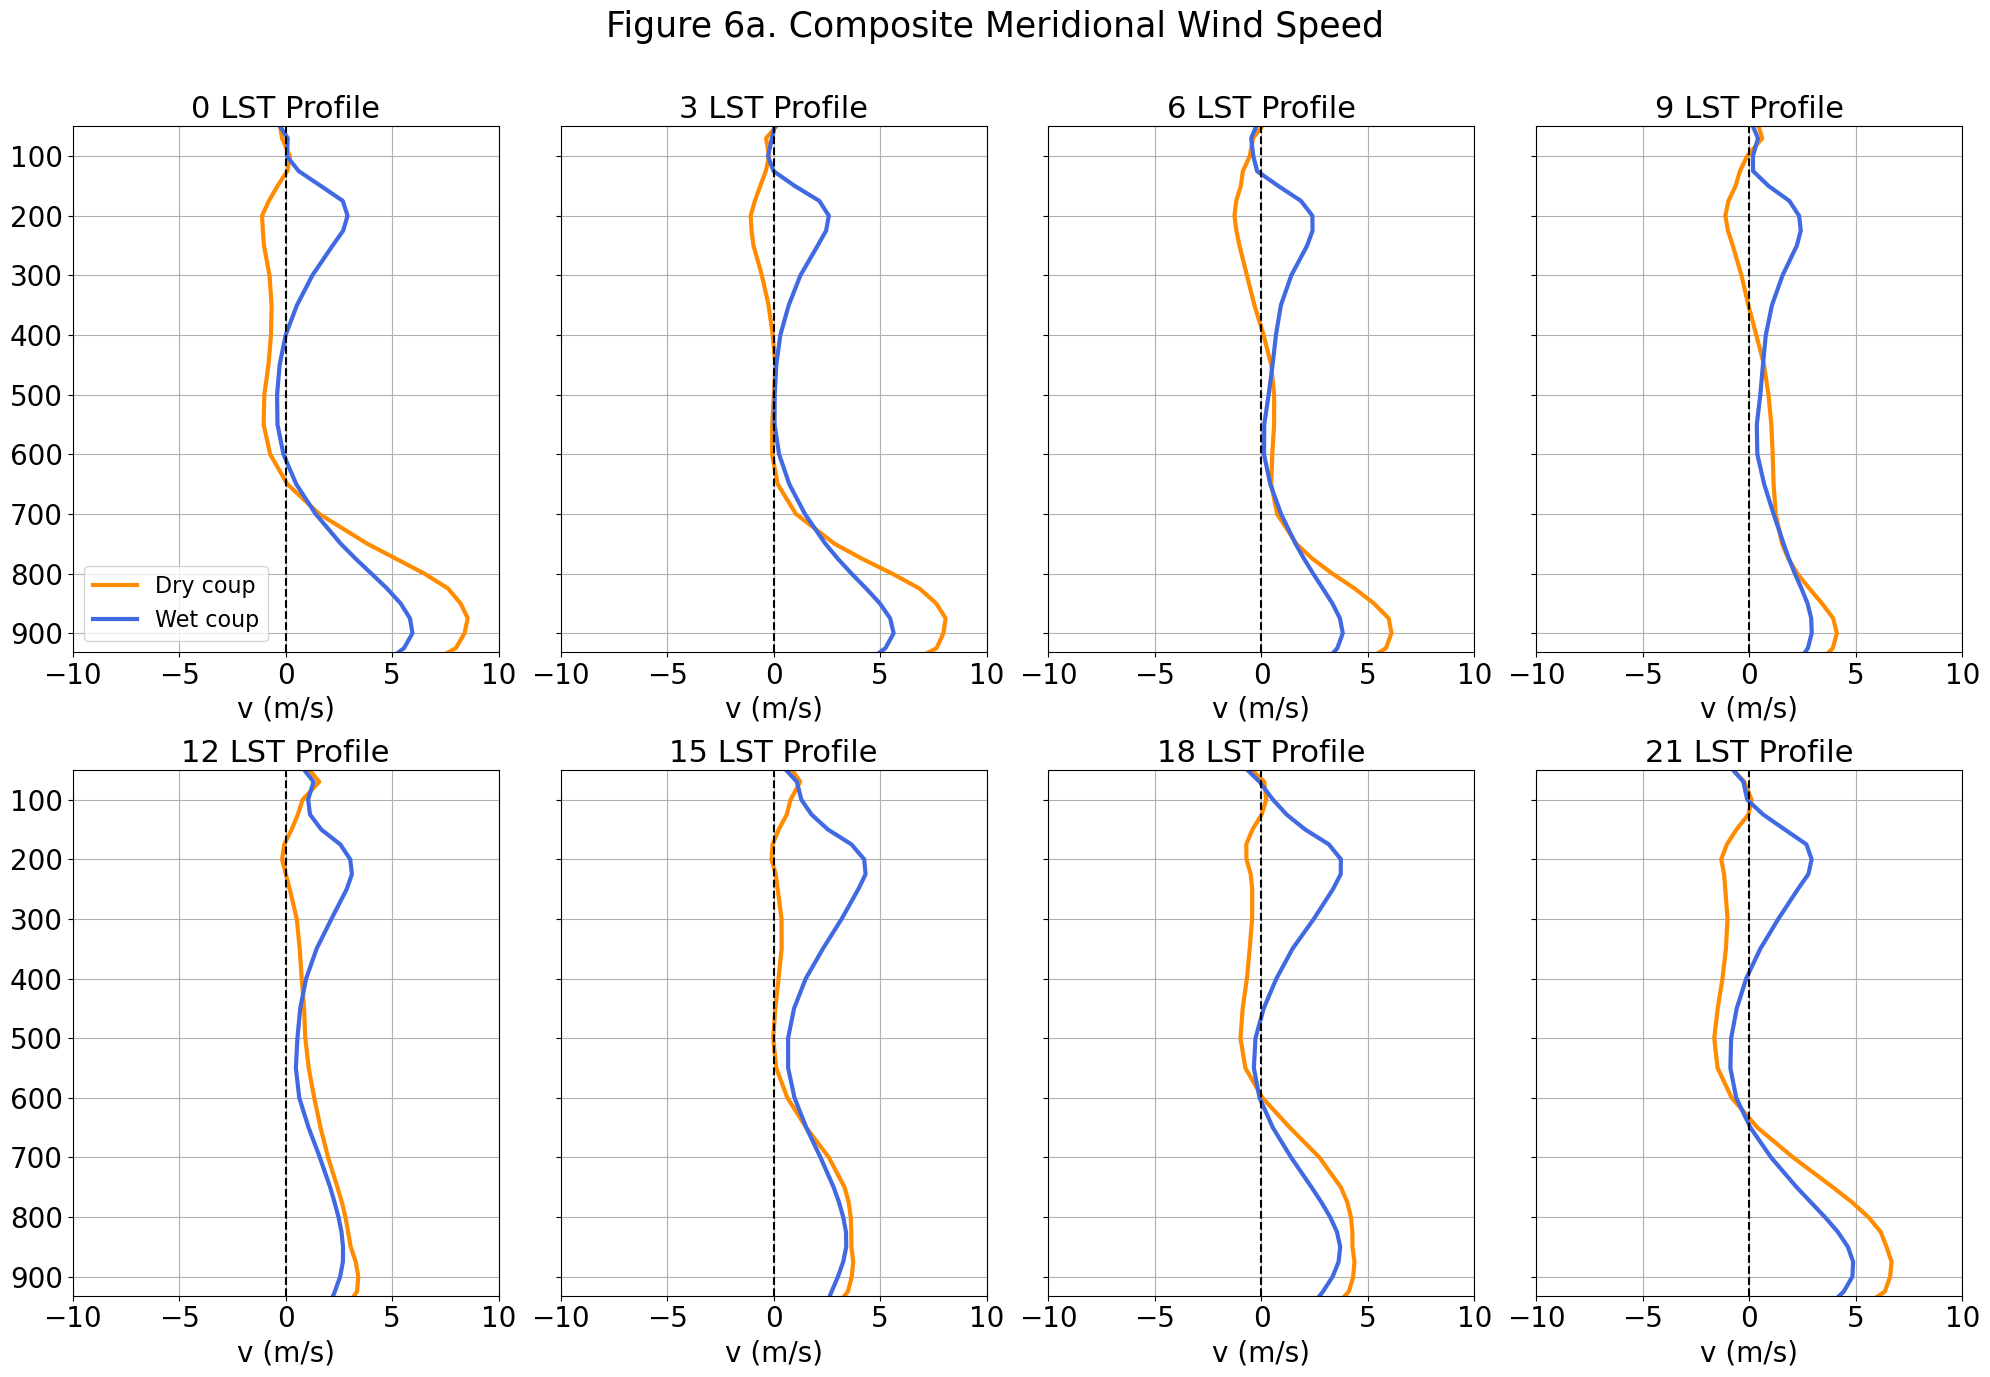

In [16]:
pressure = _0lst['level'].data  # Assuming this is consistent for both dry and wet cases

profile_columns = [col for col in v_drycoup_all_times.columns]

wet_color = "#4169E1"  # Royal Blue

dry_color = "#FF8C00"  # Dark Orange

num_profiles = len(profile_columns)

rows = 2

cols = min(4, num_profiles)  # Ensures no extra empty columns

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), sharey=True)

axes = np.ravel(axes)  # Flatten in case of 2D array

# Define pressure levels to shade
shade_min = 800  # hPa

shade_max = 600  # hPa

# Loop through each column (each time of day) and plot dry and wet profiles
for i, (ax, col) in enumerate(zip(axes, profile_columns)):
    
    # Plot the dry and wet profiles
    ax.plot(v_drycoup_all_times[col] , pressure, label=f'Dry coup', color=dry_color, linewidth=3)
    
    ax.plot(v_wetcoup_all_times[col] , pressure, label=f'Wet coup', color=wet_color, linewidth=3)
    
    ax.invert_yaxis()  # Invert for atmospheric convention
    
    ax.set_xlim(-10, 10)  # Set x-axis limits
    
    ax.set_title(f'{col} Profile', fontsize=22)  # Title with hour label
    
    ax.set_xlabel('v (m/s)', fontsize=20)  # x-label
    
    ax.tick_params(axis='both', which='major', labelsize=20)  # Tick label size
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)  # Zero reference line
    
    ax.grid(True)
    
    ax.set_ylim(mean_surface_pressure, np.min(pressure))
    
    # Add legend only to the first subplot
    if i == 0:
        
        ax.legend(fontsize=16, loc='best')

plt.tight_layout()

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Leaves space at the top for the suptitle

plt.suptitle("Figure 6a. Composite Meridional Wind Speed", fontsize=25, y=0.98)

# plt.gca().invert_yaxis()

plt.show()

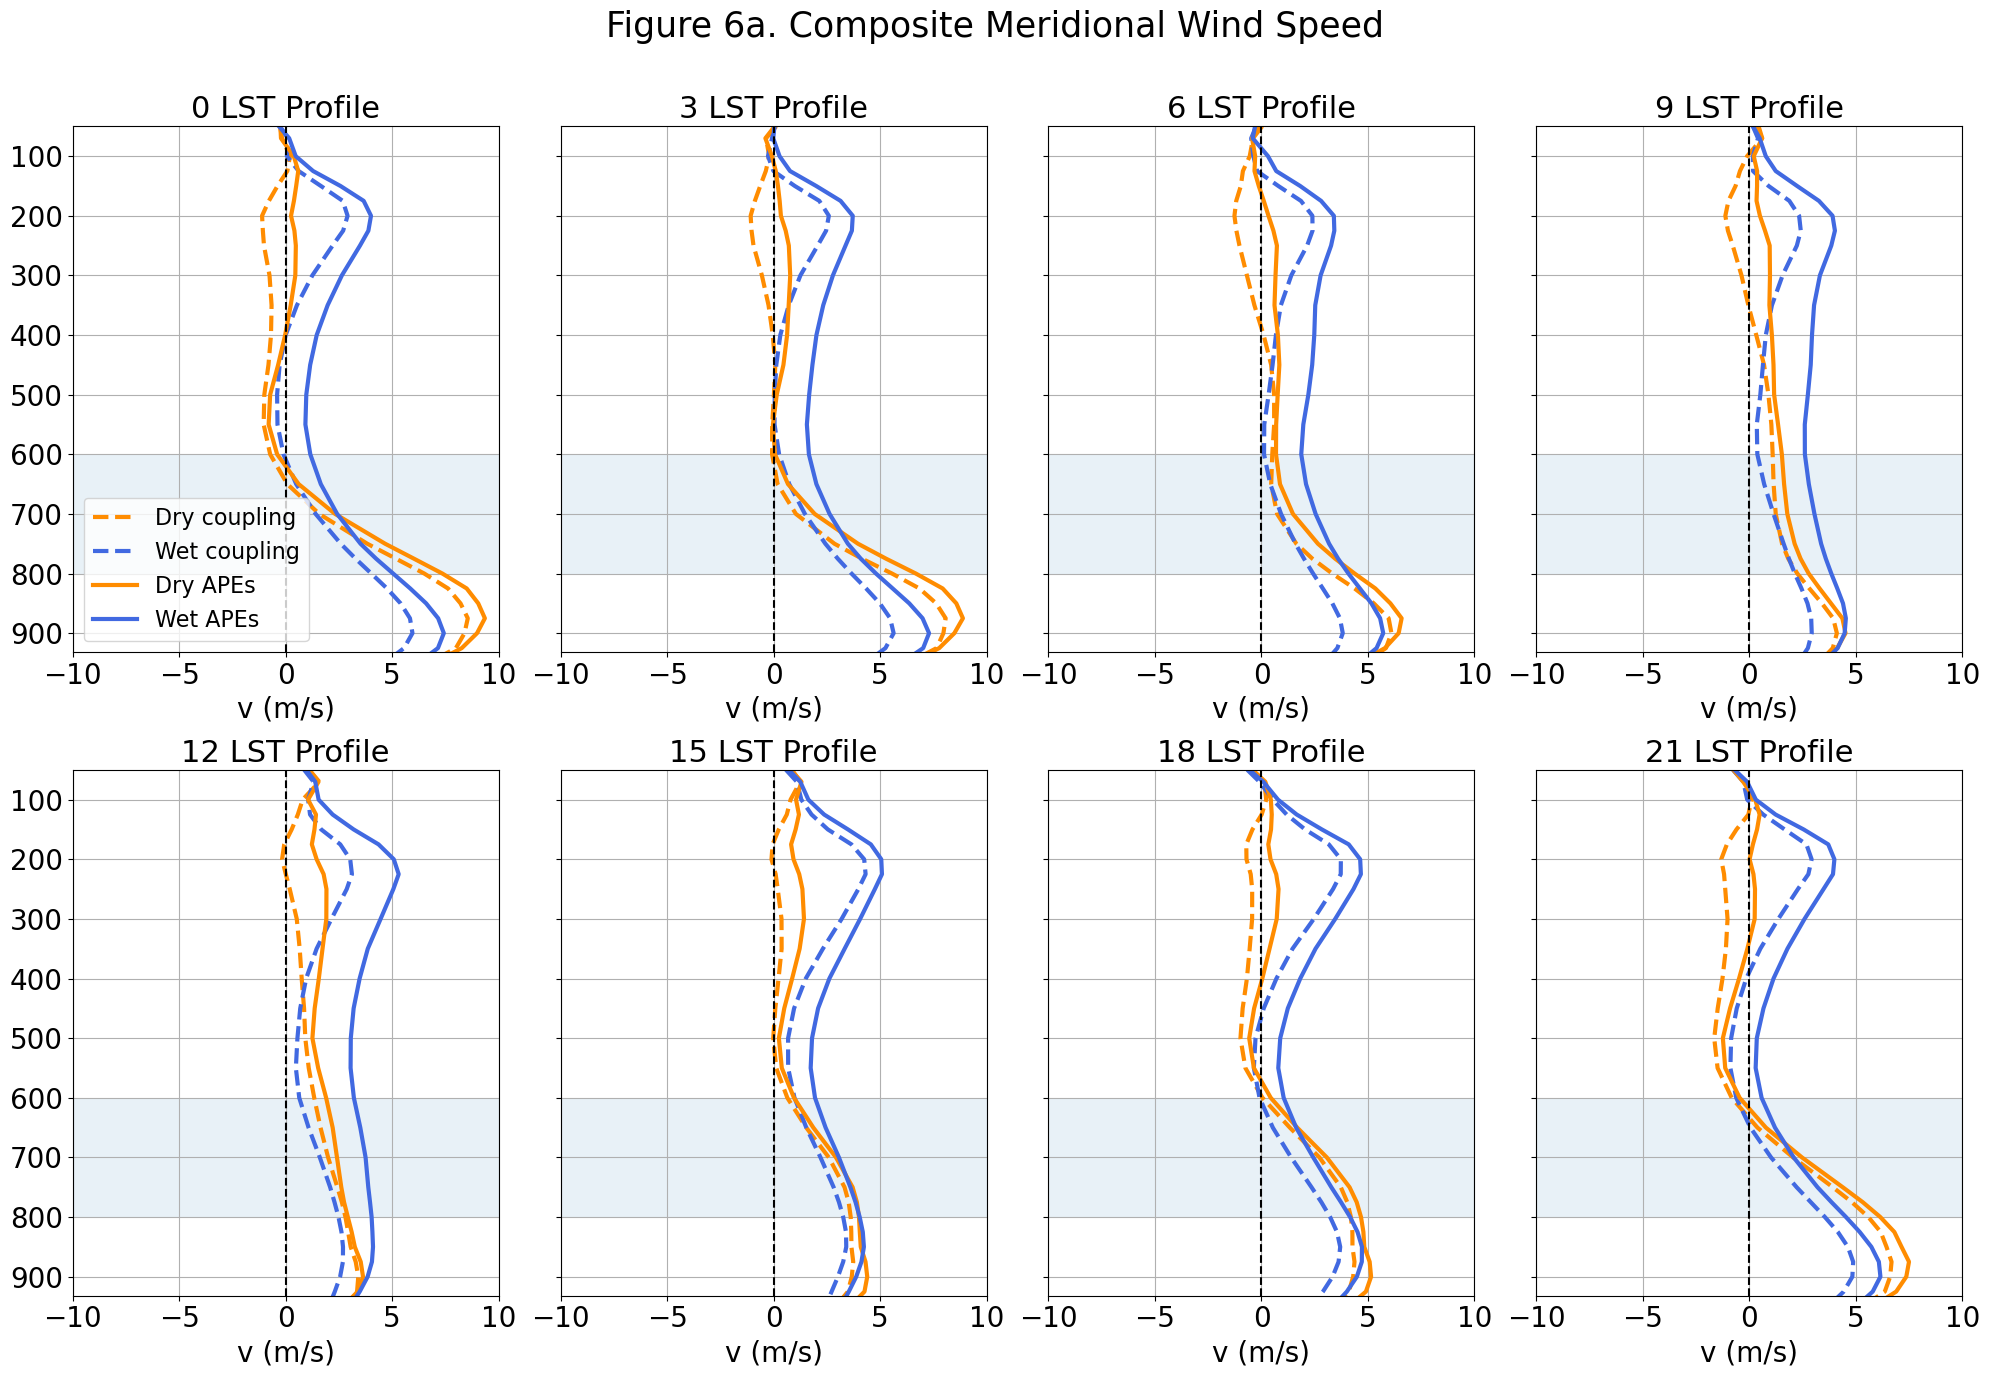

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# ASSUMED INPUTS (must already exist in your namespace)
# ------------------------------------------------------------
# _0lst : xarray Dataset/DataArray holding the pressure coordinate in `level`
# v_drycoup_all_times : pandas DataFrame (columns = times, rows = levels)
# v_wetcoup_all_times : pandas DataFrame (columns = times, rows = levels)
# v_dryapes_all_times : pandas DataFrame (columns = times, rows = levels)
# v_wet_apes_alltimes : pandas DataFrame (columns = times, rows = levels)
# mean_surface_pressure : scalar (hPa)
#
# If needed, you can alias:
# v_wet_apes_alltimes = v_wetapes_all_times

# ------------------------------------------------------------
# Pressure axis (hPa)
# ------------------------------------------------------------
pressure = _0lst["level"].data  # 1D array of pressure levels

# ------------------------------------------------------------
# Columns (times of day)
# ------------------------------------------------------------
profile_columns = list(v_drycoup_all_times.columns)
num_profiles = len(profile_columns)

# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------
wet_color = "#4169E1"   # Royal Blue
dry_color = "#FF8C00"   # Dark Orange

ls_coup = "--"   # coupling
ls_apes = "-"    # APEs

# ------------------------------------------------------------
# Subplot layout
# ------------------------------------------------------------
rows = 2
cols = min(4, num_profiles)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 7),
    sharey=True
)

axes = np.atleast_1d(axes).ravel()

# ------------------------------------------------------------
# Pressure layer shading (optional)
# ------------------------------------------------------------
shade_min = 800  # hPa
shade_max = 600  # hPa

# ------------------------------------------------------------
# Plot loop
# ------------------------------------------------------------
for i, ax in enumerate(axes[:num_profiles]):
    col = profile_columns[i]

    # ---- Shaded layer ----
    ax.axhspan(shade_max, shade_min, alpha=0.10)

    # ---- Coupling (dashed) ----
    ax.plot(
        v_drycoup_all_times[col].values,
        pressure,
        color=dry_color,
        linestyle=ls_coup,
        linewidth=3,
        label="Dry coupling"
    )

    ax.plot(
        v_wetcoup_all_times[col].values,
        pressure,
        color=wet_color,
        linestyle=ls_coup,
        linewidth=3,
        label="Wet coupling"
    )

    # ---- APEs (solid) ----
    ax.plot(
        v_dryapes_all_times[col].values,
        pressure,
        color=dry_color,
        linestyle=ls_apes,
        linewidth=3,
        label="Dry APEs"
    )

    ax.plot(
        v_wetapes_all_times[col].values,
        pressure,
        color=wet_color,
        linestyle=ls_apes,
        linewidth=3,
        label="Wet APEs"
    )

    # ---- Axes formatting ----
    ax.invert_yaxis()
    ax.set_xlim(-10, 10)
    ax.set_title(f"{col} Profile", fontsize=22)
    ax.set_xlabel("v (m/s)", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
    ax.grid(True)

    ax.set_ylim(mean_surface_pressure, np.min(pressure))

    # Legend only once
    if i == 0:
        ax.legend(fontsize=16, loc="best")

# ------------------------------------------------------------
# Hide unused panels
# ------------------------------------------------------------
for j in range(num_profiles, len(axes)):
    axes[j].set_visible(False)

# ------------------------------------------------------------
# Final layout
# ------------------------------------------------------------
plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.suptitle(
    "Figure 6a. Composite Meridional Wind Speed",
    fontsize=25,
    y=0.98
)

plt.show()


#### dryapes zonal wind speed

In [ ]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

dryapes['date'] = pd.to_datetime(dryapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    u_profiles = ds.sel(
        
        time=xr.DataArray(dryapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(dryapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(dryapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['u']
    
    sp_expanded = np.expand_dims(dryapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    u_profiles_masked = u_profiles.where(pressure_levels < sp_expanded)

    u_profiles_np = u_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(u_profiles_np, axis=0)
    
    print(time_label, "complete")

u_dryapes_all_times = pd.DataFrame(composite_profiles)

#### wetapes zonal wind speed

In [ ]:
pressure_levels = _0lst['level'].data * 100 

xr_all_times = {
    
    "0 LST": _0lst, "3 LST": _3lst, "6 LST": _6lst, "9 LST": _9lst,
    
    "12 LST": _12lst, "15 LST": _15lst, "18 LST": _18lst, "21 LST": _21lst
}

wetapes['date'] = pd.to_datetime(wetapes['date'])

composite_profiles = {}

for time_label, ds in xr_all_times.items():
    
    u_profiles = ds.sel(
        
        time=xr.DataArray(wetapes['date'].values, dims="points"),
        
        latitude=xr.DataArray(wetapes['latitude'].values, dims="points"),
        
        longitude=xr.DataArray(wetapes['longitude'].values, dims="points"),
        
        method="nearest"
    
    )['u']
    
    sp_expanded = np.expand_dims(wetapes['average_sp'].values, axis=1)  # Shape (n_cases, 1)

    u_profiles_masked = u_profiles.where(pressure_levels < sp_expanded)

    u_profiles_np = u_profiles_masked.values  # Shape: (n_cases, vertical_levels)

    # Compute the mean profile (averaged over all cases)
    
    composite_profiles[time_label] = np.nanmean(u_profiles_np, axis=0)
    
    print(time_label, "complete")

u_wetapes_all_times = pd.DataFrame(composite_profiles)

#### plot zonal wind speeds

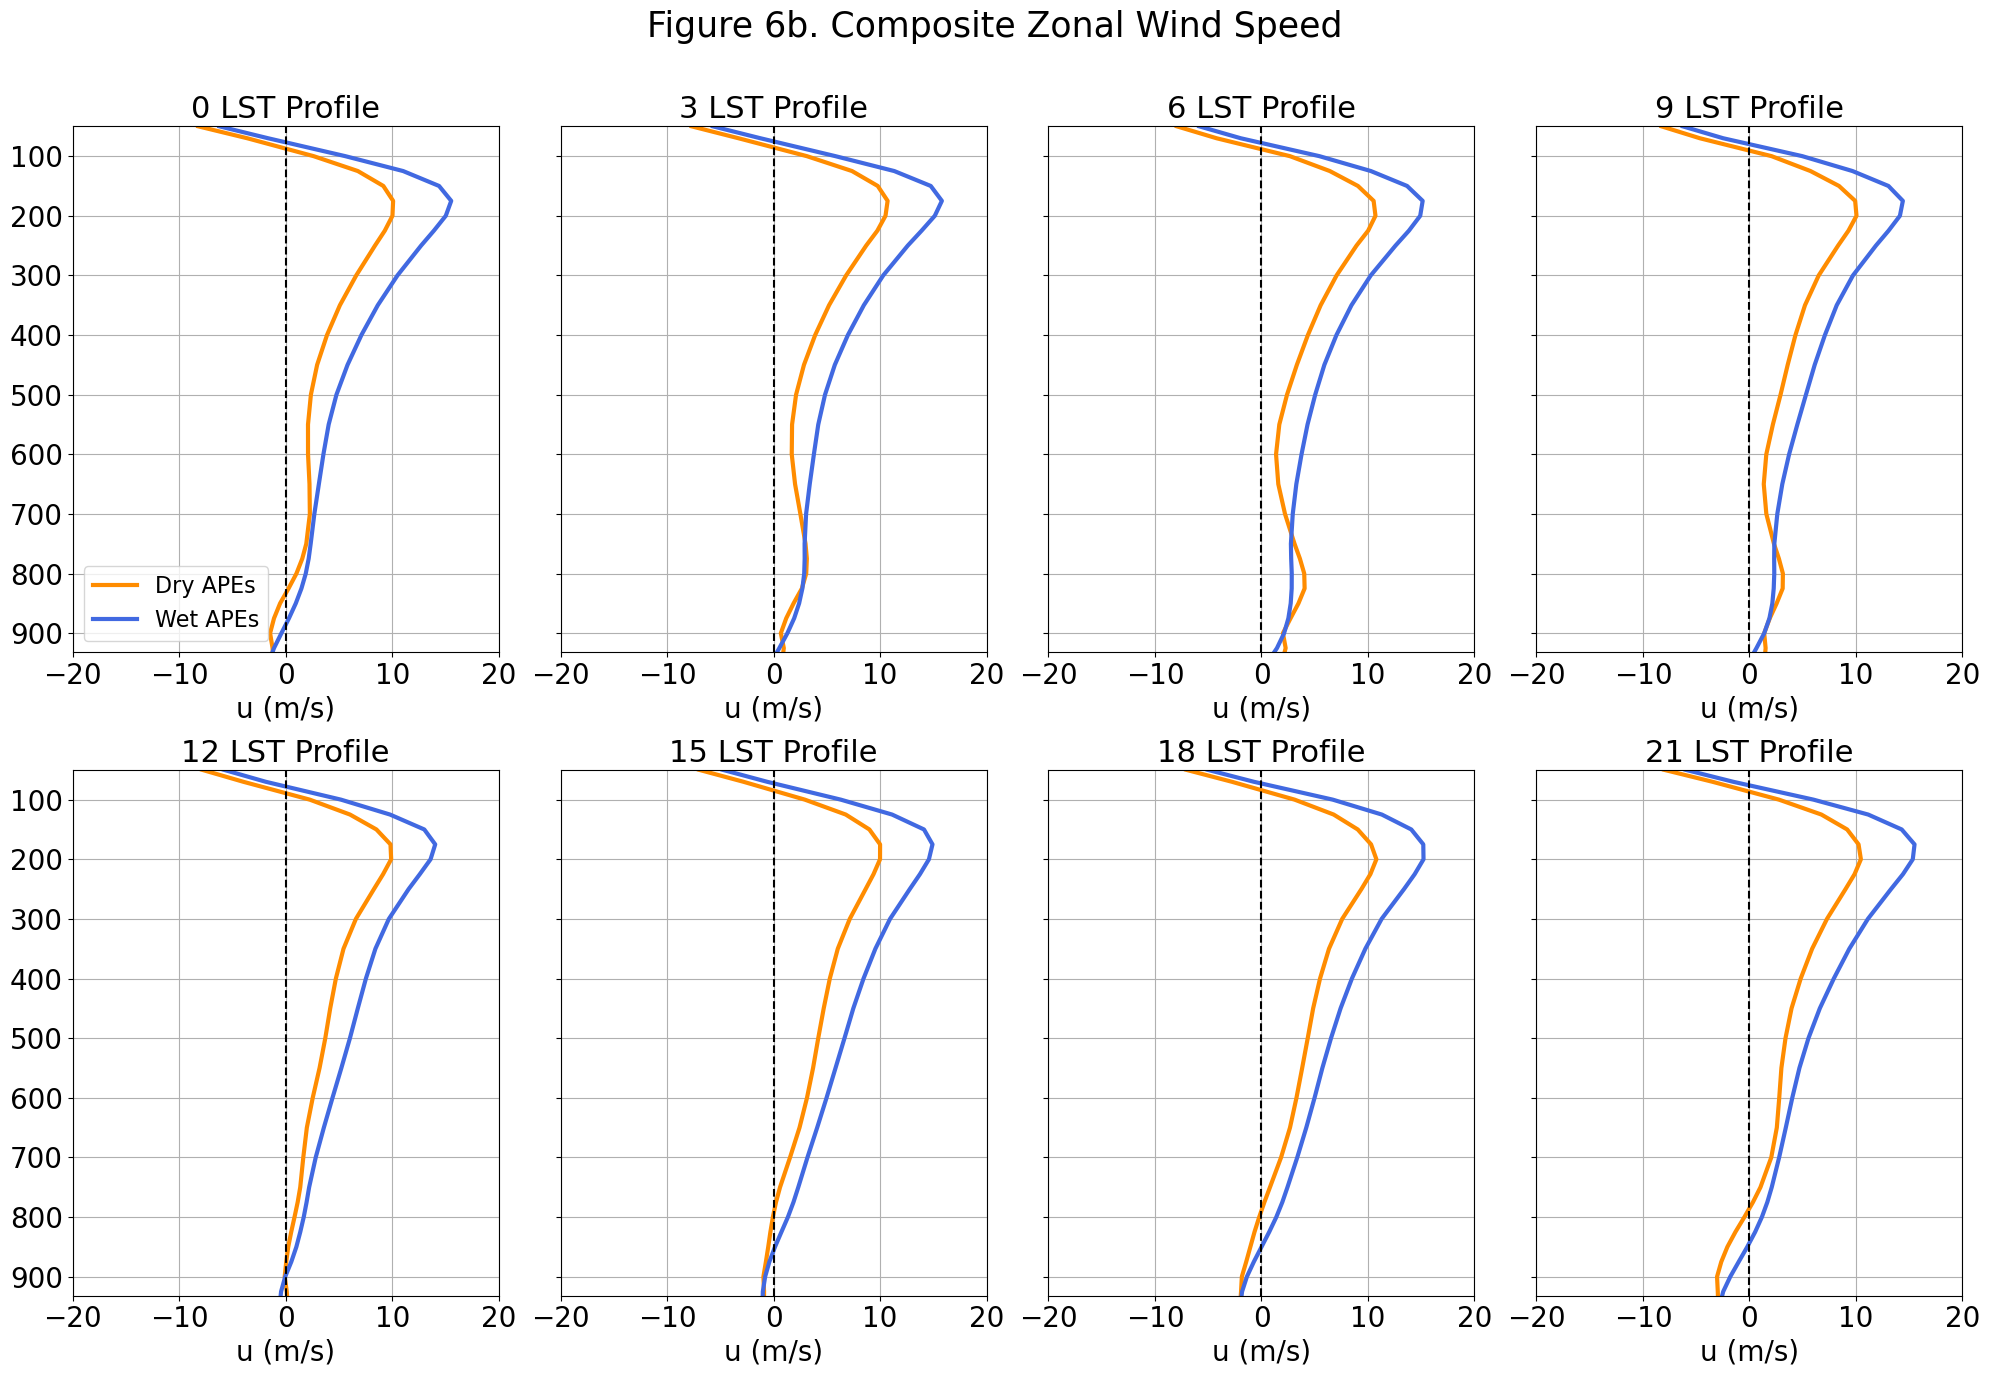

In [29]:
pressure = _0lst['level'].data  # Assuming this is consistent for both dry and wet cases

profile_columns = [col for col in u_dryapes_all_times.columns]

wet_color = "#4169E1"  # Royal Blue

dry_color = "#FF8C00"  # Dark Orange

num_profiles = len(profile_columns)

rows = 2
cols = min(4, num_profiles)  # Ensures no extra empty columns

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 7), sharey=True)
axes = np.ravel(axes)  # Flatten in case of 2D array

# Define pressure levels to shade
shade_min = 800  # hPa

shade_max = 600  # hPa

# Loop through each column (each time of day) and plot dry and wet profiles
for i, (ax, col) in enumerate(zip(axes, profile_columns)):
    
    # Plot the dry and wet profiles
    ax.plot(u_dryapes_all_times[col] , pressure, label=f'Dry APEs', color=dry_color, linewidth=3)
    
    ax.plot(u_wetapes_all_times[col] , pressure, label=f'Wet APEs', color=wet_color, linewidth=3)
    
    ax.invert_yaxis()  # Invert for atmospheric convention
    
    ax.set_xlim(-20, 20)  # Set x-axis limits
    
    ax.set_title(f'{col} Profile', fontsize=22)  # Title with hour label
    
    ax.set_xlabel('u (m/s)', fontsize=20)  # x-label
    
    ax.tick_params(axis='both', which='major', labelsize=20)  # Tick label size
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)  # Zero reference line
    
    ax.grid(True)
    
    ax.set_ylim(mean_surface_pressure, np.min(pressure))

    
    # Add legend only to the first subplot
    if i == 0:
        
        ax.legend(fontsize=16, loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Leaves space at the top for the suptitle

plt.suptitle("Figure 6b. Composite Zonal Wind Speed", fontsize=25, y=0.98)

# plt.gca().invert_yaxis()

plt.show()